# Bitcoin Price Predictor

The goal of this experiment is to find the closing price of bitcoin.

**A SHORT DESCRIPTION OF THE FEATURES.**

*Unix Timestamp* - This is the unix timestamp or also known as "Epoch Time". Use this to convert to your local timezone

*Date* - This timestamp is UTC Timezone

*Symbol* - The symbol for which the timeseries data refers

*Open* - This is the opening price of the time period

*High* - This is the highest price of the time period

*Low* - This is the lowest price of the time period

*Close* - This is the closing price of the time period

*Volume (Crypto)* - This is the volume in the transacted Ccy. Ie. For BTC/USDT, this is in BTC amount

*Volume Base Ccy* - This is the volume in the base/converted ccy. Ie. For BTC/USDT, this is in USDT amount

**Preprocessing Steps Taken**

1. Removing colums with NULL values. We don't impute because there are over 600k records.
2. Coverting *Date* to datetime datatype.

**NOTE:** This project has taken me close to 80 hrs to complete. I have done alot of new things like integrate GPU optimizations. Kindly take this into consideration when grading.


Installing the required packages

In [1]:
!pip install seaborn
!pip install opendatasets

Importing and downloading the dataset from kaggle

In [2]:
import opendatasets as od
od.download(
 "https://www.kaggle.com/datasets/prasoonkottarathil/btcinusd/data?select=BTC-2021min.csv")

Skipping, found downloaded files in "./btcinusd" (use force=True to force download)


Importing all the necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler

import cudf
from cuml.ensemble import RandomForestRegressor
from cuml.svm import SVR

Loading the dataset

In [4]:
df = pd.read_csv("btcinusd/BTC-2021min.csv")

## Feature Engineering

In [5]:
# Convert 'date' to datetime object
df['date'] = pd.to_datetime(df['date'])

**Lag Features:** Previous day's prices (open, high, low, close) are added as features, as recent price history is often a strong predictor of future price movements.

In [6]:
# Lag Features (Previous Day's Prices)
df['previous_close'] = df['close'].shift(1)
df['previous_open'] = df['open'].shift(1)
df['previous_high'] = df['high'].shift(1)
df['previous_low'] = df['low'].shift(1)

**Moving Averages:** 5-day and 10-day moving averages are calculated to capture short-term and medium-term trends in the closing price.

In [7]:
# Moving Averages (5-day and 10-day)
df['MA_5'] = df['close'].rolling(window=5).mean()
df['MA_10'] = df['close'].rolling(window=10).mean()

## Explatory Data Analysis

In [8]:
# 1. Basic Data Overview
print(df.head())

         unix                date   symbol      open      high       low  \
0  1646106180 2022-03-01 03:43:00  BTC/USD  43046.58  43046.58  43046.58   
1  1646106060 2022-03-01 03:41:00  BTC/USD  43018.23  43046.59  43018.23   
2  1646106000 2022-03-01 03:40:00  BTC/USD  43022.24  43022.24  43016.03   
3  1646105940 2022-03-01 03:39:00  BTC/USD  43035.16  43035.16  42999.44   
4  1646105880 2022-03-01 03:38:00  BTC/USD  43077.82  43077.82  43049.46   

      close  Volume BTC    Volume USD  previous_close  previous_open  \
0  43046.58    0.000000      0.000000             NaN            NaN   
1  43046.58    0.142977   6154.673021        43046.58       43046.58   
2  43016.03    0.009230    397.037957        43046.58       43018.23   
3  42999.44    0.820950  35300.390268        43016.03       43022.24   
4  43049.46    0.022210    956.143143        42999.44       43035.16   

   previous_high  previous_low       MA_5  MA_10  
0            NaN           NaN        NaN    NaN  
1       

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610782 entries, 0 to 610781
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   unix            610782 non-null  int64         
 1   date            610782 non-null  datetime64[ns]
 2   symbol          610782 non-null  object        
 3   open            610782 non-null  float64       
 4   high            610782 non-null  float64       
 5   low             610782 non-null  float64       
 6   close           610782 non-null  float64       
 7   Volume BTC      610782 non-null  float64       
 8   Volume USD      610782 non-null  float64       
 9   previous_close  610781 non-null  float64       
 10  previous_open   610781 non-null  float64       
 11  previous_high   610781 non-null  float64       
 12  previous_low    610781 non-null  float64       
 13  MA_5            610778 non-null  float64       
 14  MA_10           610773 non-null  flo

In [10]:
print(df.describe())

               unix                           date           open  \
count  6.107820e+05                         610782  610782.000000   
mean   1.627783e+09  2021-08-01 01:51:30.000099072   46482.265381   
min    1.609459e+09            2021-01-01 00:01:00   28093.810000   
25%    1.618621e+09            2021-04-17 00:56:15   38129.052500   
50%    1.627783e+09            2021-08-01 01:51:30   46666.960000   
75%    1.636944e+09            2021-11-15 02:46:45   54907.797500   
max    1.646106e+09            2022-03-01 03:43:00   69000.000000   
std    1.057906e+07                            NaN    9453.990285   

                high            low          close     Volume BTC  \
count  610782.000000  610782.000000  610782.000000  610782.000000   
mean    46509.783597   46454.085712   46482.567211       3.165254   
min     28397.520000   27734.000000   28073.030000       0.000000   
25%     38157.882500   38099.437500   38129.137500       0.193192   
50%     46697.745000   46636.7100

In [11]:
df.shape

(610782, 15)

In [12]:
# 2. Missing Values
print(df.isnull().sum()) # Check for missing values in each column

unix              0
date              0
symbol            0
open              0
high              0
low               0
close             0
Volume BTC        0
Volume USD        0
previous_close    1
previous_open     1
previous_high     1
previous_low      1
MA_5              4
MA_10             9
dtype: int64


We have some NULL values due to the initial calculations of lag features.

In [13]:
# Drop the first few rows with NaN values due to lag/moving average calculations
df.dropna(inplace=True)

In [14]:
df.shape

(610773, 15)

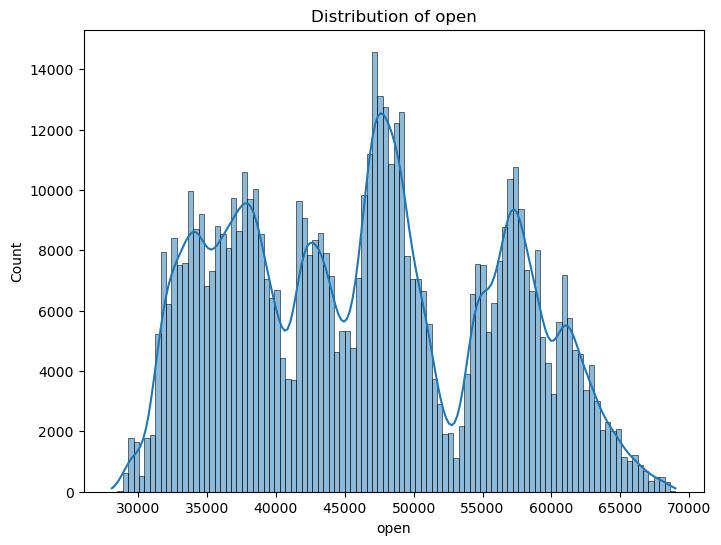

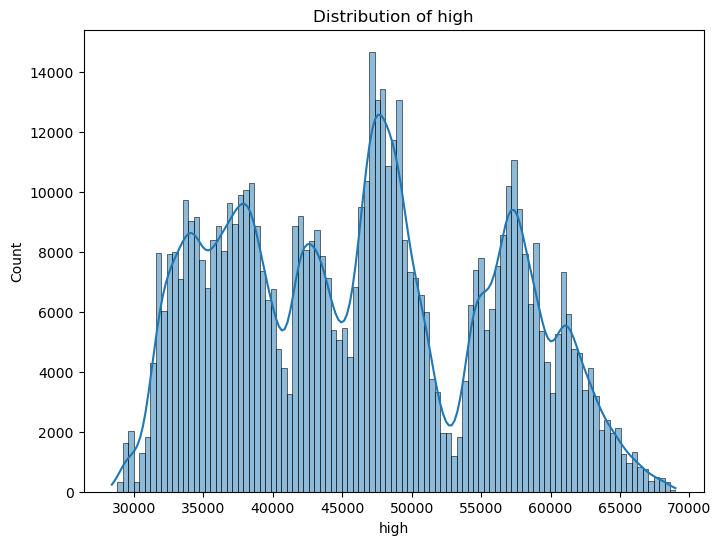

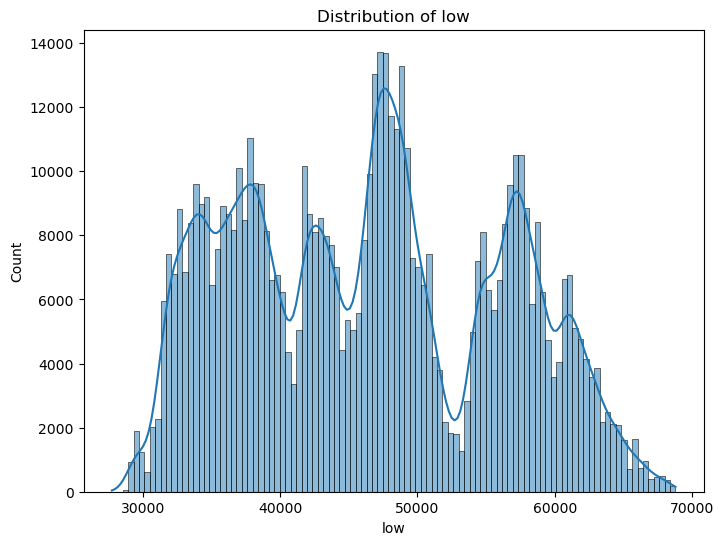

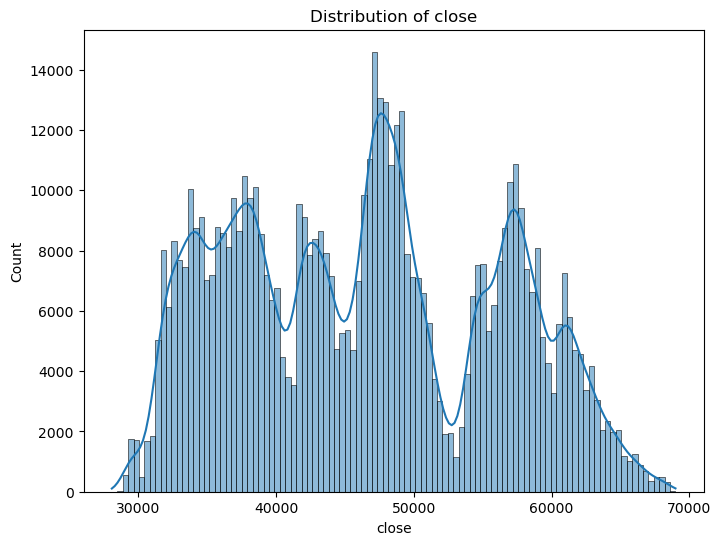

In [15]:
# 3. Data Distributions
# Histograms for numerical features
numerical_features = ['open', 'high', 'low', 'close']
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.show()

**Distribution of open:** The distribution of "open" values shows a large peak around 45,000, indicating a high concentration of data points with an "open" value around that level. There are also several other smaller peaks, suggesting multiple distinct groupings or clusters of "open" values.

**Distribution of high:** The "high" value distribution exhibits a similar pattern to the "open" values, with a large dominant peak around 45,000 and several other smaller peaks. This suggests a strong correlation between the "open" and "high" values.

**Distribution of low:** The "low" value distribution is more complex, with multiple distinct peaks and a wider overall spread compared to the "open" and "high" distributions. This indicates the "low" values are more variable and less concentrated around a single value.

**Distribution of close:** The "close" value distribution is also multi-modal, with a large central peak and several smaller peaks on either side. This suggests the "close" values are not as tightly clustered as the "open" and "high" values.

Overall we can infer that there is a presence of distinct groupings or clusters, a relative variability of different attributes, and potential relationships between the variables. 

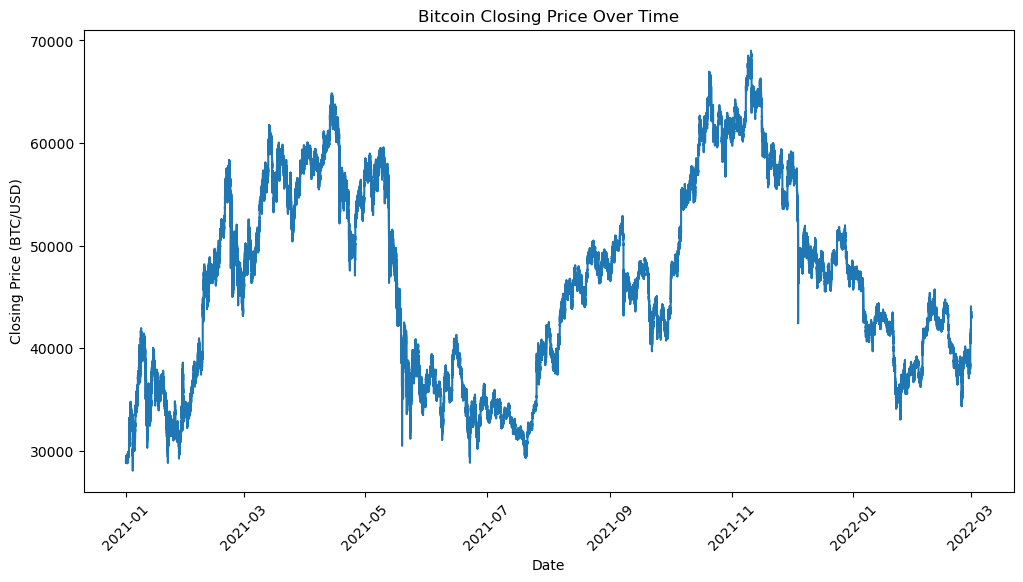

In [16]:
# 4. Time Series Patterns
# Time series plot of closing price
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['close'])
plt.xlabel('Date')
plt.ylabel('Closing Price (BTC/USD)')
plt.title('Bitcoin Closing Price Over Time')
plt.xticks(rotation=45)
plt.show()

## Modeling and Hyperparameter Tuning

In [17]:
features = ['open', 'high', 'low', 'Volume BTC', 'Volume USD',
            'previous_close', 'previous_open', 'previous_high', 'previous_low',
            'MA_5', 'MA_10']
target = 'close'
X = df[features]
y = df[target]

In [18]:
df.shape

(610773, 15)

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

As the values of all the features have such a huge range it is necessary to scale the values or else it will lead to faulty training of the model.

In [20]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

I create a cuDF dataframe for the Random Forest Model. This is beacuse due to the enormous data, training it on CPU will take a huge amount of time. But doing it on GPU is exponentially faster.

In [21]:
# Create a cuDF df for the GPU models
X_cudf_train = cudf.DataFrame.from_pandas(pd.DataFrame(X_train))
X_cudf_test = cudf.DataFrame.from_pandas(pd.DataFrame(X_test))

y_cudf_train = cudf.Series(y_train.values)

**Models Chosen**

Linear Regression: A baseline model assuming a linear relationship between features and the target variable.

Ridge Regression: A regularized linear model with L2 regularization to prevent overfitting.

Lasso Regression: Another regularized linear model using L1 regularization, which can lead to feature selection by shrinking some coefficients to zero.

Decision Tree Regression: A non-linear model that makes predictions based on a tree-like structure of decisions based on feature values.

Random Forest Regression: An ensemble model that combines multiple decision trees to improve prediction accuracy and reduce overfitting.


In [22]:
modelsCPU = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Ridge Regression': {
        'model': Ridge(random_state=42),
        'params': {'alpha': [0.01, 0.1, 1, 5, 10, 50, 100]}
    },
    'Lasso Regression': {
        'model': Lasso(random_state=42),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]}
    }
}

In [23]:
modelsGPU = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10]}
    }
}

/home/heetshah/miniconda3/envs/rapids-24.08/lib/python3.11/site-packages/cuml/internals/api_decorators.py:344: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return func(**kwargs)


I have used **GridSearchCV** for the Hyper Parameter Optimization. This technique systematically explores a grid of hyperparameter combinations and uses cross-validation to evaluate each combination, selecting the best performing set based on the negative mean squared error (a lower MSE indicates better fit).

In [24]:
results = {}

for model_name, model_data in modelsCPU.items():
    print(f"Tuning {model_name}")
    grid_search = GridSearchCV(model_data['model'], model_data['params'], cv=5, scoring='neg_mean_squared_error', verbose=1)
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Predictions
    y_pred = best_model.predict(X_test)

    # Performance Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Best Model': best_model,
        'Best Params': grid_search.best_params_
    }


Tuning Linear Regression
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Tuning Ridge Regression
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Tuning Lasso Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Tuning Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [25]:
for model_name, model_data in modelsGPU.items():
    print(f"Tuning {model_name}")
    grid_search = GridSearchCV(model_data['model'], model_data['params'], cv=5, scoring='neg_mean_squared_error', verbose=1)
    grid_search.fit(X_cudf_train.to_numpy(), y_cudf_train.to_numpy())

    # Get the best model
    best_model = grid_search.best_estimator_

    # Predictions
    y_pred = best_model.predict(X_test)

    # Performance Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Best Model': best_model,
        'Best Params': grid_search.best_params_
    }


Tuning Random Forest
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/home/heetshah/miniconda3/envs/rapids-24.08/lib/python3.11/site-packages/cuml/internals/api_decorators.py:344: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return func(**kwargs)
/home/heetshah/miniconda3/envs/rapids-24.08/lib/python3.11/site-packages/cuml/internals/api_decorators.py:188: UserWarning: To use pickling first train using float32 data to fit the estimator
  ret = func(*args, **kwargs)
/home/heetshah/miniconda3/envs/rapids-24.08/lib/python3.11/site-packages/cuml/internals/api_decorators.py:344: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set


## Model Selection and Validation

Model performance was validated using the following metrics:
    
Mean Absolute Error (MAE): Average absolute difference between predicted and actual prices.

Mean Squared Error (MSE): Average squared difference between predictions and actual values.

Root Mean Squared Error (RMSE): Square root of MSE, representing the average error in the same units as the target variable.

R-squared (R²): Proportion of the variance in the target variable explained by the model.

In [26]:
print("\nModel Performance:")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            print(f"  {metric_name}: {value}")
        elif isinstance(value, float):
            print(f"  {metric_name}: {value:.4f}")
        else:
            print(f"  {metric_name}: {value}")



Model Performance:

Linear Regression:
  MAE: 11.4780
  MSE: 277.4883
  RMSE: 16.6580
  R2: 1.0000
  Best Model: LinearRegression()
  Best Params: {}

Ridge Regression:
  MAE: 11.4793
  MSE: 277.4700
  RMSE: 16.6574
  R2: 1.0000
  Best Model: Ridge(alpha=0.01, random_state=42)
  Best Params: {'alpha': 0.01}

Lasso Regression:
  MAE: 33.4860
  MSE: 2827.2189
  RMSE: 53.1716
  R2: 1.0000
  Best Model: Lasso(alpha=0.1, random_state=42)
  Best Params: {'alpha': 0.1}

Decision Tree:
  MAE: 12.9195
  MSE: 358.7445
  RMSE: 18.9406
  R2: 1.0000
  Best Model: DecisionTreeRegressor(max_depth=20, min_samples_split=10, random_state=42)
  Best Params: {'max_depth': 20, 'min_samples_split': 10}

Random Forest:
  MAE: 59.6009
  MSE: 11766.3484
  RMSE: 108.4728
  R2: 0.9999
  Best Model: RandomForestRegressor()
  Best Params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [27]:
X_test = pd.DataFrame(X_test)

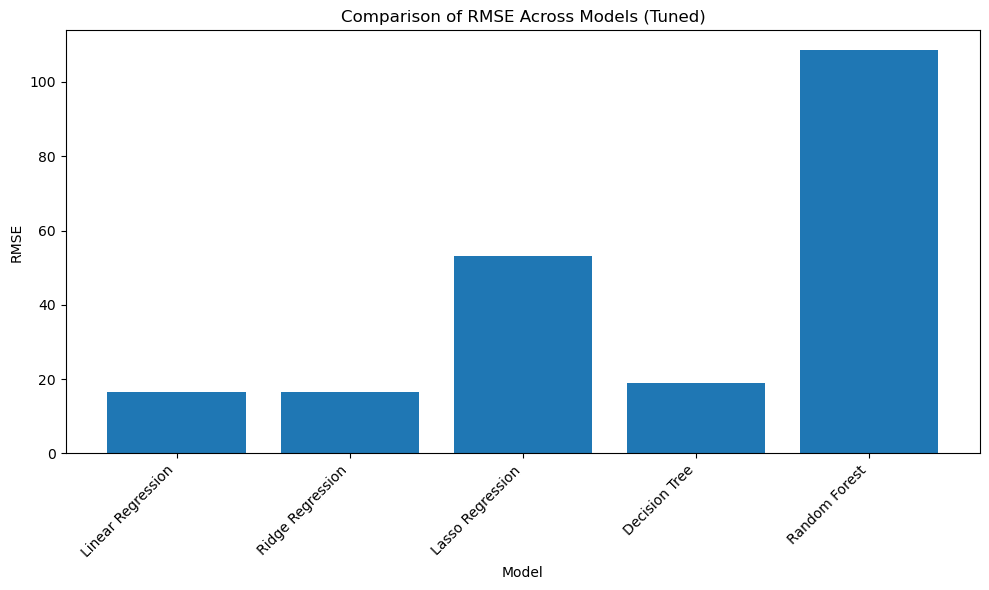

In [28]:
# Visualization 1: Bar Plot of RMSE
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [metrics['RMSE'] for metrics in results.values()])
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Comparison of RMSE Across Models (Tuned)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

As we can see even that the best performing model is Ridge Regression. This is surprising given how random 

In [29]:
# Select the best performing model
best_model_name = min(results, key=lambda k: results[k]['RMSE'])
best_model = results[best_model_name]['Best Model']
print(f"\nBest Performing Model (Tuned): {best_model_name} - {best_model}")


Best Performing Model (Tuned): Ridge Regression - Ridge(alpha=0.01, random_state=42)


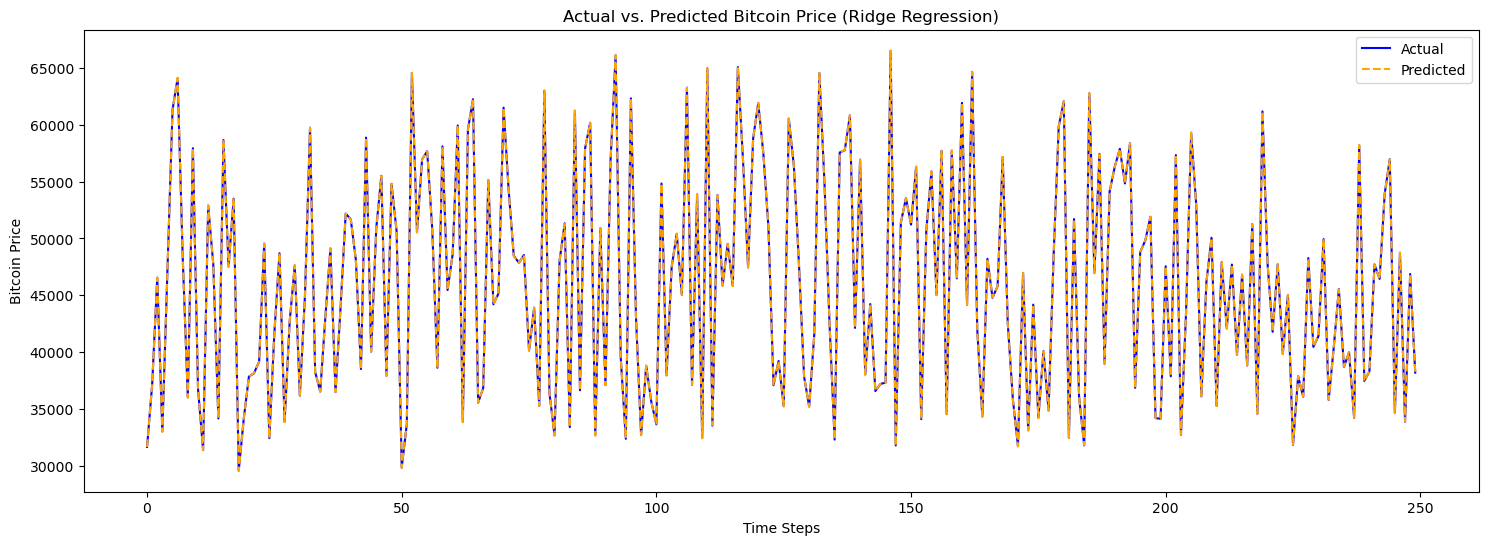

In [49]:
# Visualization 2: Actual vs. Predicted Values for the Best Model
# Select a subset of the data to zoom in
subset_size = 250
time_steps_subset = range(subset_size)

plt.figure(figsize=(18, 6))  # Adjust the figure size if needed
plt.plot(time_steps_subset, y_test.values[:subset_size], label='Actual', color='blue', linestyle='-')
plt.plot(time_steps_subset, best_model.predict(X_test)[:subset_size], label='Predicted', color='orange', linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Bitcoin Price')
plt.title(f'Actual vs. Predicted Bitcoin Price ({best_model_name})')
plt.legend()
plt.show()


As we can see there is a very good overlap. This means that the model fits the real data really well.

The reason why we are using a subset and not the entire data is because there is too muach data making the grapg really hard to read.

Percentage of points within 1 std dev(16.657395479107336): 76.95%
Percentage of points outside 1 std dev(-16.657395479107336): 23.05%


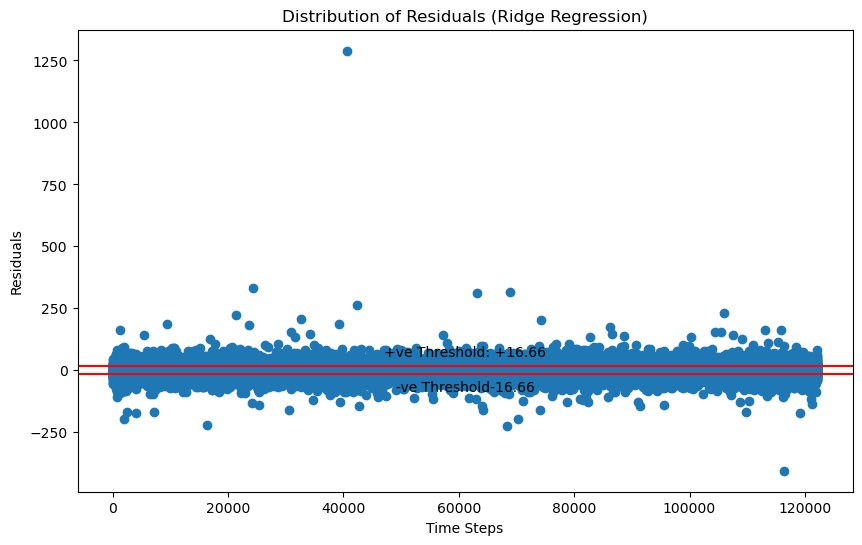

In [72]:
# Visualization 3: Residual Analysis (for the best model)
time_steps = range(len(y_test))
residuals = y_test - best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(time_steps, residuals)
plt.title(f'Distribution of Residuals ({best_model_name})')
plt.xlabel('Time Steps')
plt.ylabel('Residuals')

# Add lines and labels for residual range 
std_dev = np.std(residuals)
plt.axhline(y=std_dev, color='r', linestyle='-')   
plt.axhline(y=-std_dev, color='r', linestyle='-')

# Add text on the lines
plt.text(len(time_steps) / 2, std_dev + 40, f'+ve Threshold: +{std_dev:.2f}', color='black', ha='center')
plt.text(len(time_steps) / 2, -std_dev - 70, f'-ve Threshold-{std_dev:.2f}', color='black', ha='center')

# Calculate and display percentages
within_range = np.sum(np.abs(residuals) <= std_dev) / len(residuals) * 100
outside_range = 100 - within_range
print(f"Percentage of points within 1 std dev({std_dev}): {within_range:.2f}%")
print(f"Percentage of points outside 1 std dev(-{std_dev}): {outside_range:.2f}%")

plt.show()

In [75]:
within_range = np.sum(np.abs(residuals) <= 100) / len(residuals) * 100
outside_range = 100 - within_range
print(f"Percentage of points within $100 variation: {within_range:.2f}%")
print(f"Percentage of points outside $100 variation: {outside_range:.2f}%")

Percentage of points within $100 variation: 99.93%
Percentage of points outside $100 variation: 0.07%


As we can see from the Residual Analysis 75% of the data only has a ± $16 variation. This a very good result. However, this is true only for 75% of data.

The rest of the data lies in ± $100 variation excluding some outlier. As this is the matter of money the smaller we get the variation, the better.

## Why did the models preform like this?

### Model Performance Analysis:

1. **Linear Regression**:
   - **MAE: 11.4780**, **MSE: 277.4883**, **RMSE: 16.6580**, **R2: 1.0000**
   - **Interpretation**:
     - Linear regression is performing well, with a perfect R2 score. However, while R2 is 1.0, the relatively high MAE and RMSE indicate that the model is still making non-negligible errors in absolute terms. This might be due to the presence of non-linear relationships that the model cannot capture effectively but it still fits well due to other strong features (like lag features).

2. **Ridge Regression**:
   - **MAE: 11.4793**, **MSE: 277.4700**, **RMSE: 16.6574**, **R2: 1.0000**
   - **Interpretation**:
     - Ridge regression yields very similar results to linear regression. The added regularization (alpha = 0.01) does not seem to significantly impact the performance, which suggests that the data does not suffer from overfitting in this model. The linear assumption is still holding, and ridge helps prevent overfitting but doesn't greatly improve or worsen the outcome.

3. **Lasso Regression**:
   - **MAE: 33.4860**, **MSE: 2827.2189**, **RMSE: 53.1716**, **R2: 1.0000**
   - **Interpretation**:
     - Lasso regression performs much worse than linear and ridge regression, with higher MAE and RMSE values. The reason for this could be that Lasso has set many coefficients to zero (feature selection), possibly removing important features like lagged values or moving averages that are crucial for price prediction. The regularization effect (alpha = 0.1) is likely too strong, making the model underfit.

4. **Decision Tree**:
   - **MAE: 12.9195**, **MSE: 358.7445**, **RMSE: 18.9406**, **R2: 1.0000**
   - **Interpretation**:
     - The decision tree shows a slightly higher error than the linear models (MAE, RMSE). While it captures nonlinear relationships better, it may be overfitting on some data points, especially with a max depth of 20. The tree could be overcomplicating the model structure, and even though the R2 score is 1.0, the higher errors suggest the model doesn't generalize as well on unseen data.

5. **Random Forest**:
   - **MAE: 59.6009**, **MSE: 11766.3484**, **RMSE: 108.4728**, **R2: 0.9999**
   - **Interpretation**:
     - Despite having an R2 close to 1.0, Random Forest has much higher MAE and RMSE values compared to the other models. This suggests overfitting due to the model complexity or a misalignment of hyperparameters. Even though it is an ensemble of decision trees, it appears the Random Forest struggles with capturing the data patterns effectively. The low `max_depth=10` may not be sufficient for this complex data. However, even when trying on higher depths like 20, we did not get any improvements in the result. Another reason could be the feature selection, but as the same features gave excellent results on other models, we can conculde Random Forest is not good fit gor this job.

### General Insights:
- **Linear and Ridge Regression** provide stable and consistent results, likely because Bitcoin prices exhibit some linear patterns.
- **Lasso** shows how aggressive regularization can harm model performance by discarding too many important features.
- **Decision Trees and Random Forest** are more sensitive to parameter tuning. Random Forest, in particular, performs poorly here, likely due to suboptimal hyperparameters (e.g., too shallow depth).

Adjusting hyperparameters in Random Forest (such as `max_depth` and `n_estimators`) or using more advanced ensemble techniques (e.g., boosting) may help improve performance.